# Cached Prediction EDA (All Genes, Inverse ComBat)

Streamlined analysis notebook for cached LORO outputs with all-genes model fits, evaluated in inverse-ComBat GTEx space.


In [1]:
from pathlib import Path
import sys
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.eval_utils.results_eda import *


In [2]:
import importlib
import src.eval_utils.results_eda
importlib.reload(src.eval_utils.results_eda)

<module 'src.eval_utils.results_eda' from '/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/results_eda.py'>

In [3]:
set_academic_style()

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    hvg_path='data/raw/ahba_100hvg.txt',
    cache_root='out/loro_subject_cache',
    gene_scope='allgenes',
    naive_cache_dirname='naive',
    dlam_cache_dirname='dlam',
    plam_cache_dirname='plam'
)
CFG
print('analysis scope:', CFG.gene_scope)
print('inverse_combat evaluation:', True)


analysis scope: allgenes
inverse_combat evaluation: True


## 1) Dataset Attributes


In [4]:
PREPOST = prepare_pre_post_harmonization(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])


subjects: 318
genes: 13618
parcels: 150


In [5]:
# label_mode: 'ahba' | 'gtex' | 'both'
LABEL_MODE = 'both'
ELIGIBLE_ONLY = True

count_df = parcel_subject_count_table(PREPOST, label_mode=LABEL_MODE, eligible_only=ELIGIBLE_ONLY)
n_pool = int(count_df['n_subjects_pool'].iloc[0])
print(f'n (subjects in pool) = {n_pool}; eligible_only={ELIGIBLE_ONLY}')
count_df[['parcel_idx','ahba_parcel','gtex_native','n_subjects_observed','n_samples','label']].head(10)


n (subjects in pool) = 318; eligible_only=True


,parcel_idx,ahba_parcel,gtex_native,n_subjects_observed,n_samples,label
0,10,LH-Ca,caudate (basal ganglia),279,279,LH-Ca: caudate (basal ganglia)
1,18,LH-NAC,nucleus accumbens (basal ganglia),273,273,LH-NAC: nucleus accumbens (basal ganglia)
2,5,Cerebellar_Region5,cerebellar hemisphere,262,262,Cerebellar_Region5: cerebellar hemisphere
3,38,LH_Default_PFC_5,frontal cortex (ba9),252,252,LH_Default_PFC_5: frontal cortex (ba9)
4,0,Cerebellar_Region1,cerebellum,251,251,Cerebellar_Region1: cerebellum
5,19,LH-Pu,putamen (basal ganglia),250,250,LH-Pu: putamen (basal ganglia)
6,16,LH-HTH,hypothalamus,242,242,LH-HTH: hypothalamus
7,31,LH_Cont_PFCl_1,cortex,240,240,LH_Cont_PFCl_1: cortex
8,55,LH_Hippocampus,hippocampus,240,240,LH_Hippocampus: hippocampus
9,132,RH_SalVentAttn_Med_2,anterior cingulate cortex (ba24),223,223,RH_SalVentAttn_Med_2: anterior cingulate corte...


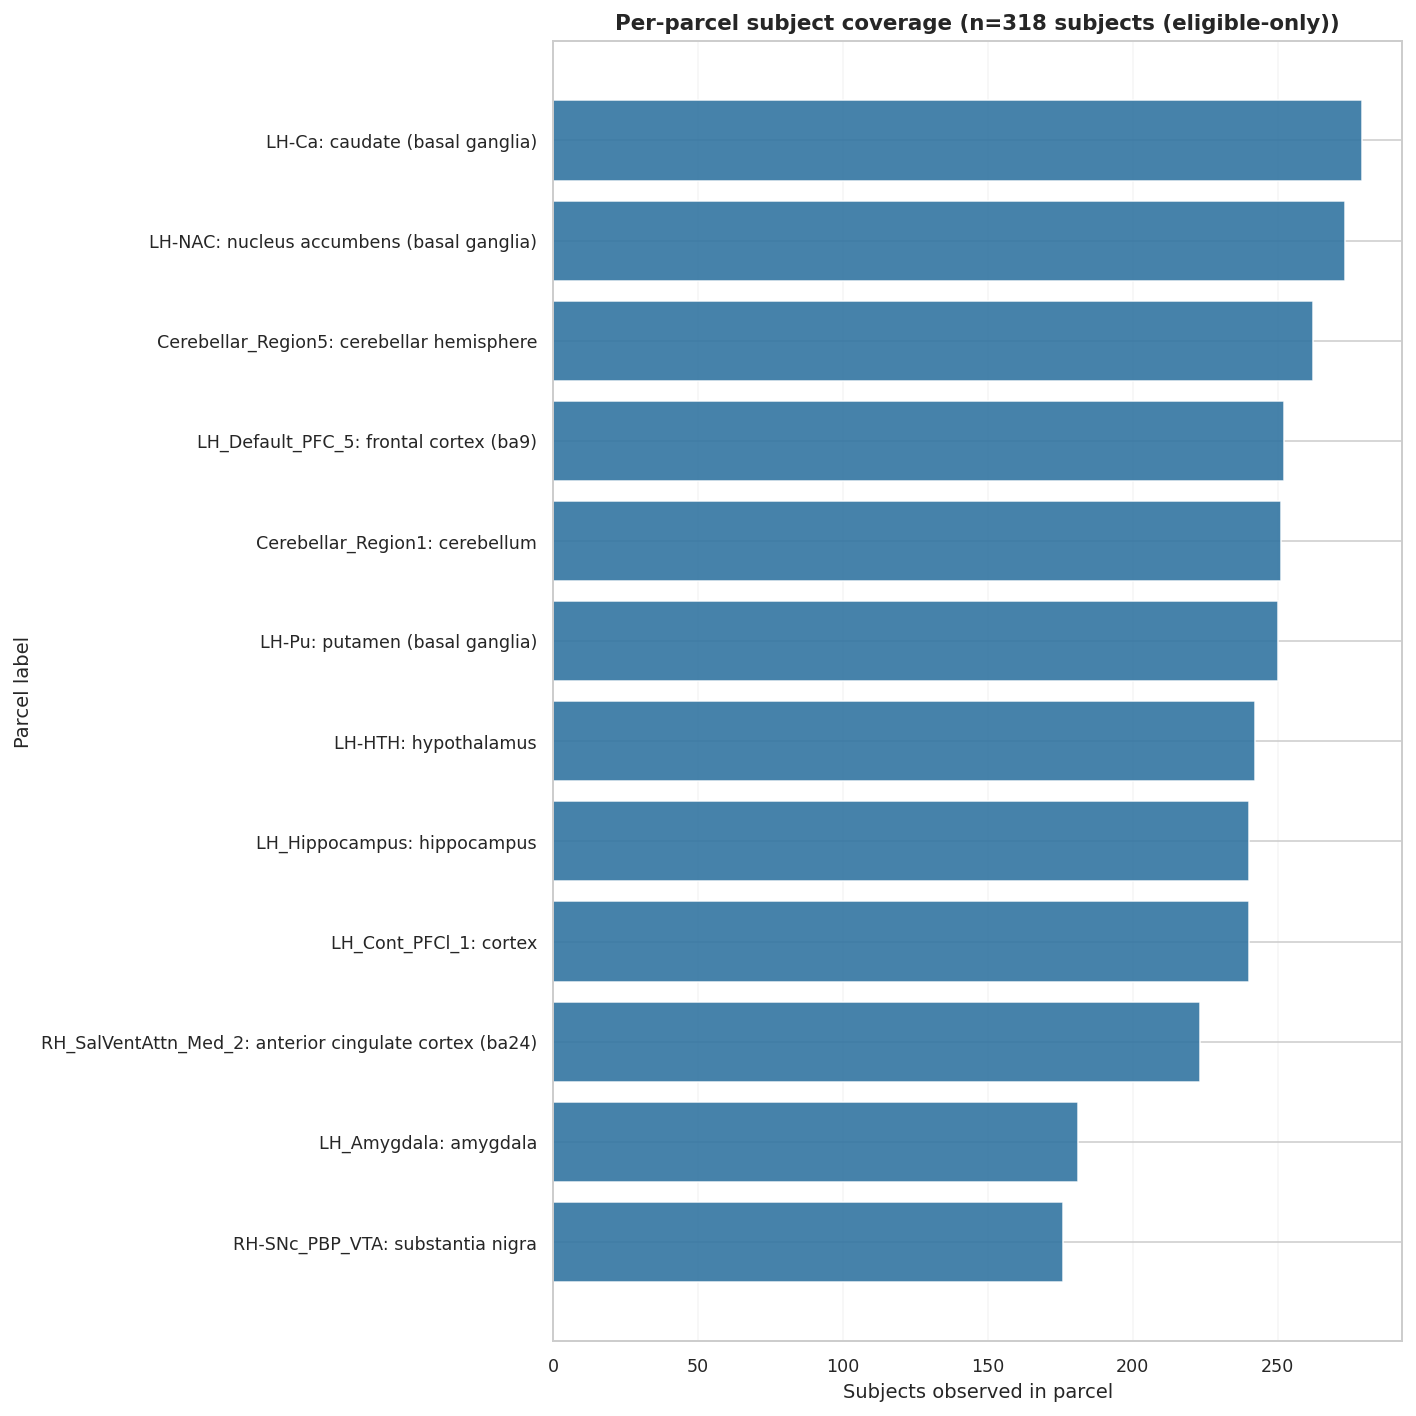

In [6]:
fig_h = max(8.0, 0.20 * len(count_df))
fig, ax = plot_parcel_subject_counts(count_df, top_n=None, min_subjects=1, figsize=(10, 10))


,n_regions_sampled,n_subjects,eligible_only,n_subjects_pool
0,5,21,True,318
1,6,29,True,318
2,7,36,True,318
3,8,29,True,318
4,9,53,True,318
5,10,54,True,318
6,11,63,True,318
7,12,33,True,318


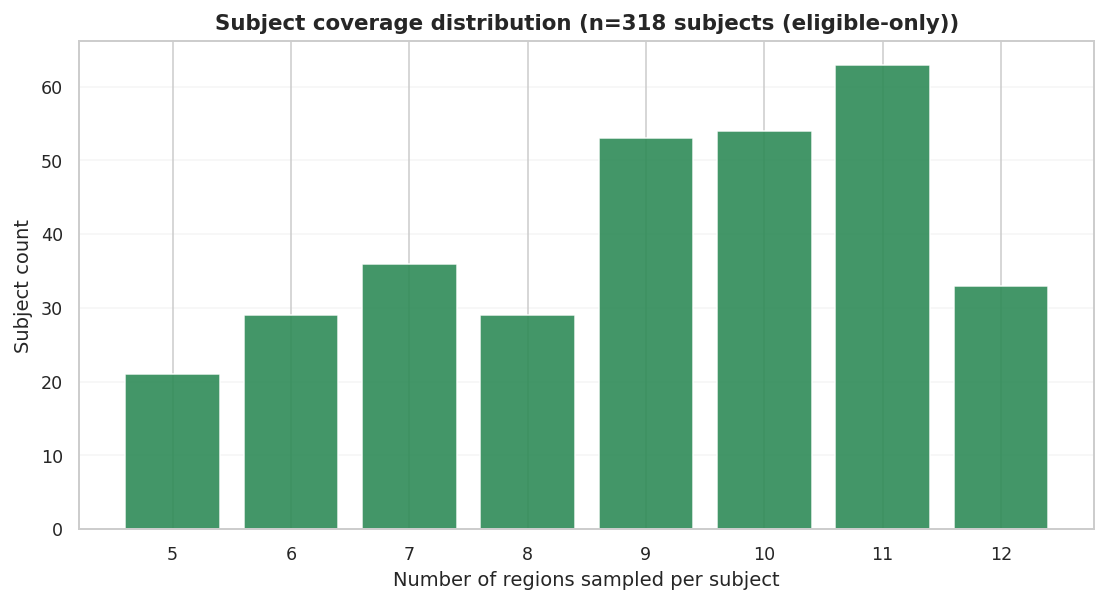

In [7]:
# LORO-relevant: x=regions sampled per subject, y=subject count
subj_cov = subject_region_count_distribution(PREPOST, eligible_only=ELIGIBLE_ONLY)
display(subj_cov)
fig, ax = plot_subject_region_count_distribution(subj_cov)


## 2) Pre/Post ComBat Diagnostics


In [8]:
# gene_mode: 'hvg' | 'allgenes' | 'custom'
GENE_MODE = 'hvg'
CUSTOM_GENE_LIST = None

atlas_cmp = prepare_atlas_median_comparison(
    PREPOST,
    gene_mode=GENE_MODE,
    gene_list=CUSTOM_GENE_LIST,
    observed_only=True,
)
print('atlas parcels:', len(atlas_cmp['parcel_labels']))
print('genes in panel:', len(atlas_cmp['genes']))


atlas parcels: 12
genes in panel: 88


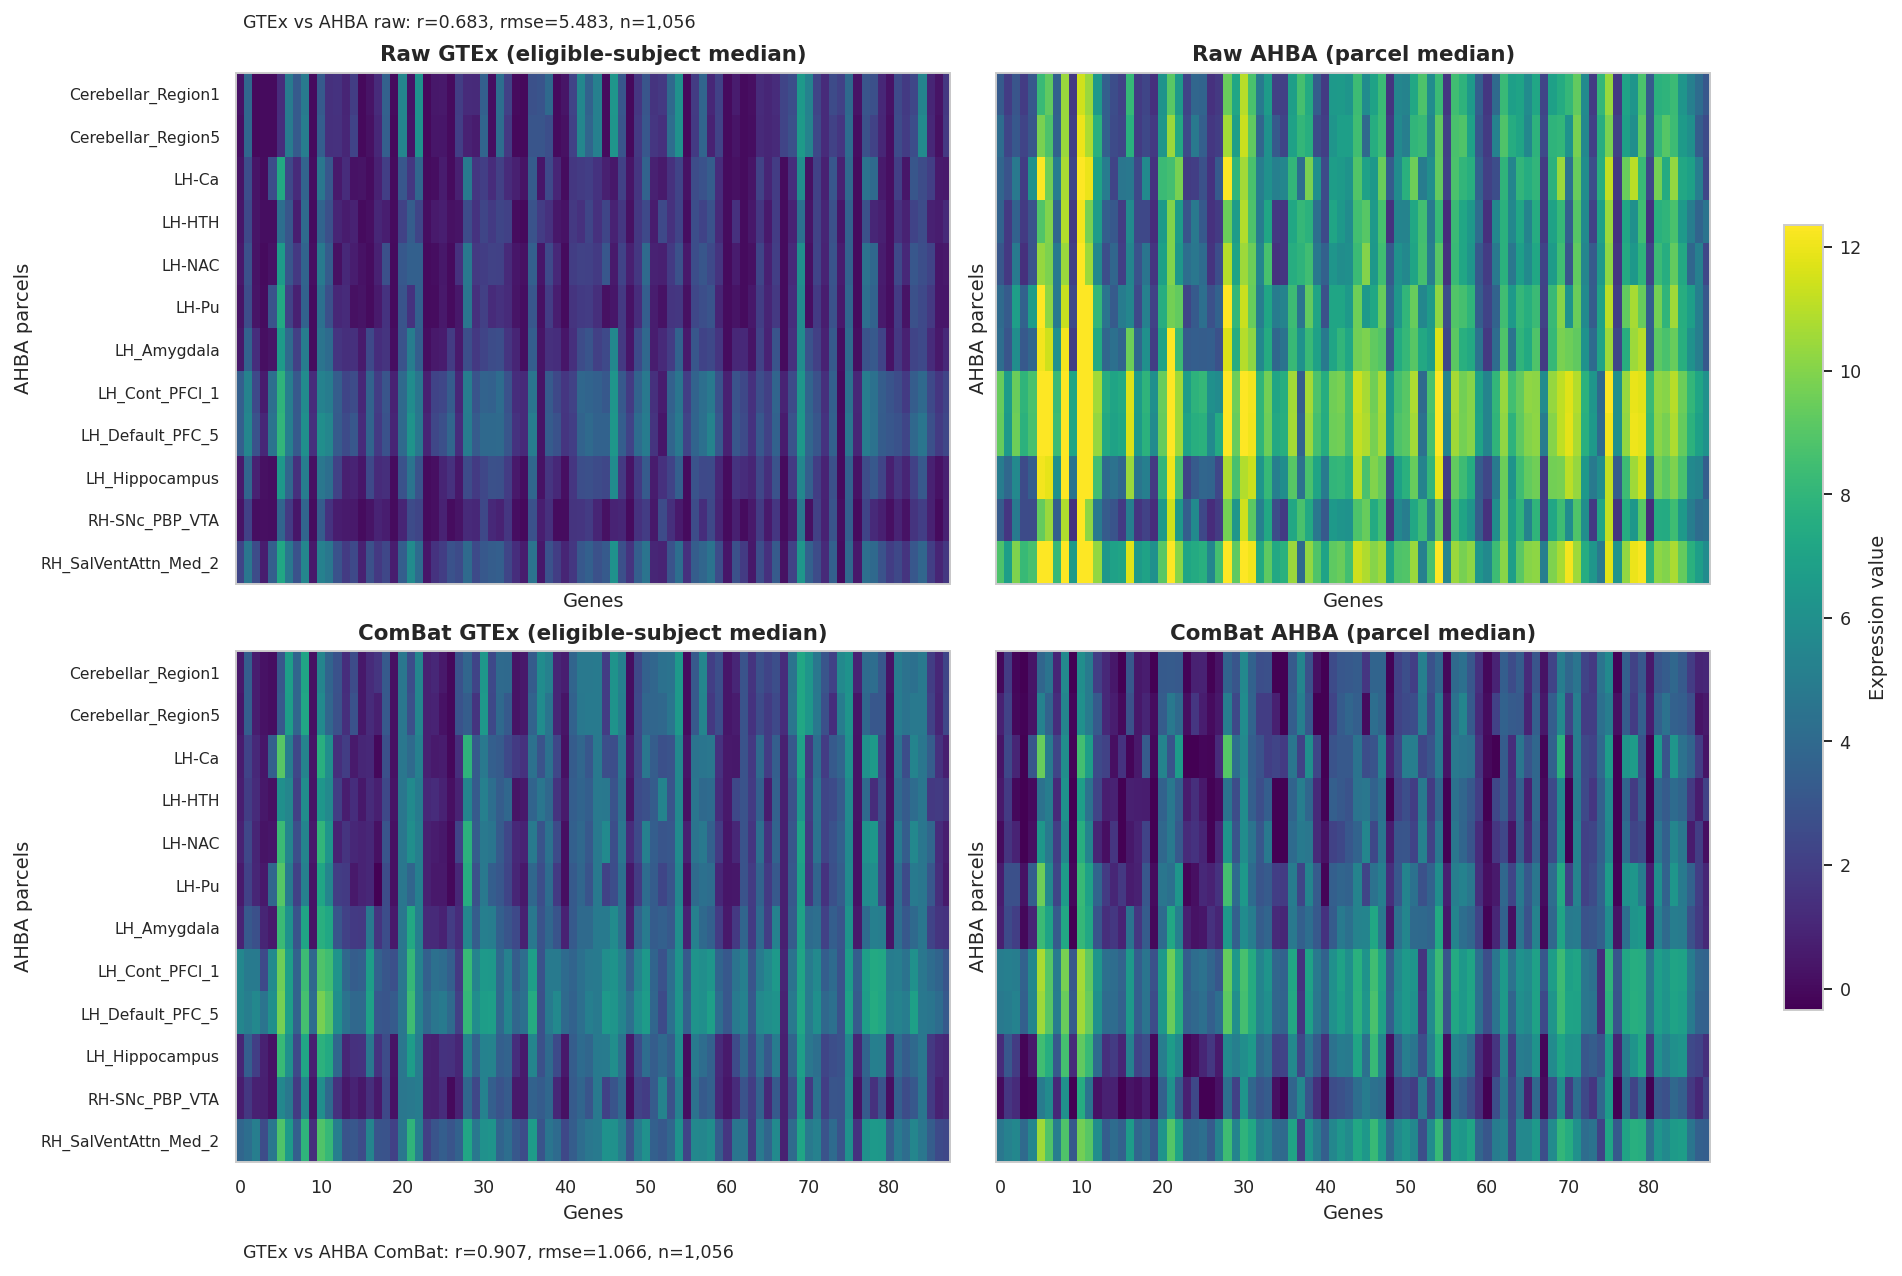

In [9]:
fig, axes = plot_atlas_median_comparison_heatmaps(atlas_cmp, label_stride=1)


subject: GTEX-1117F


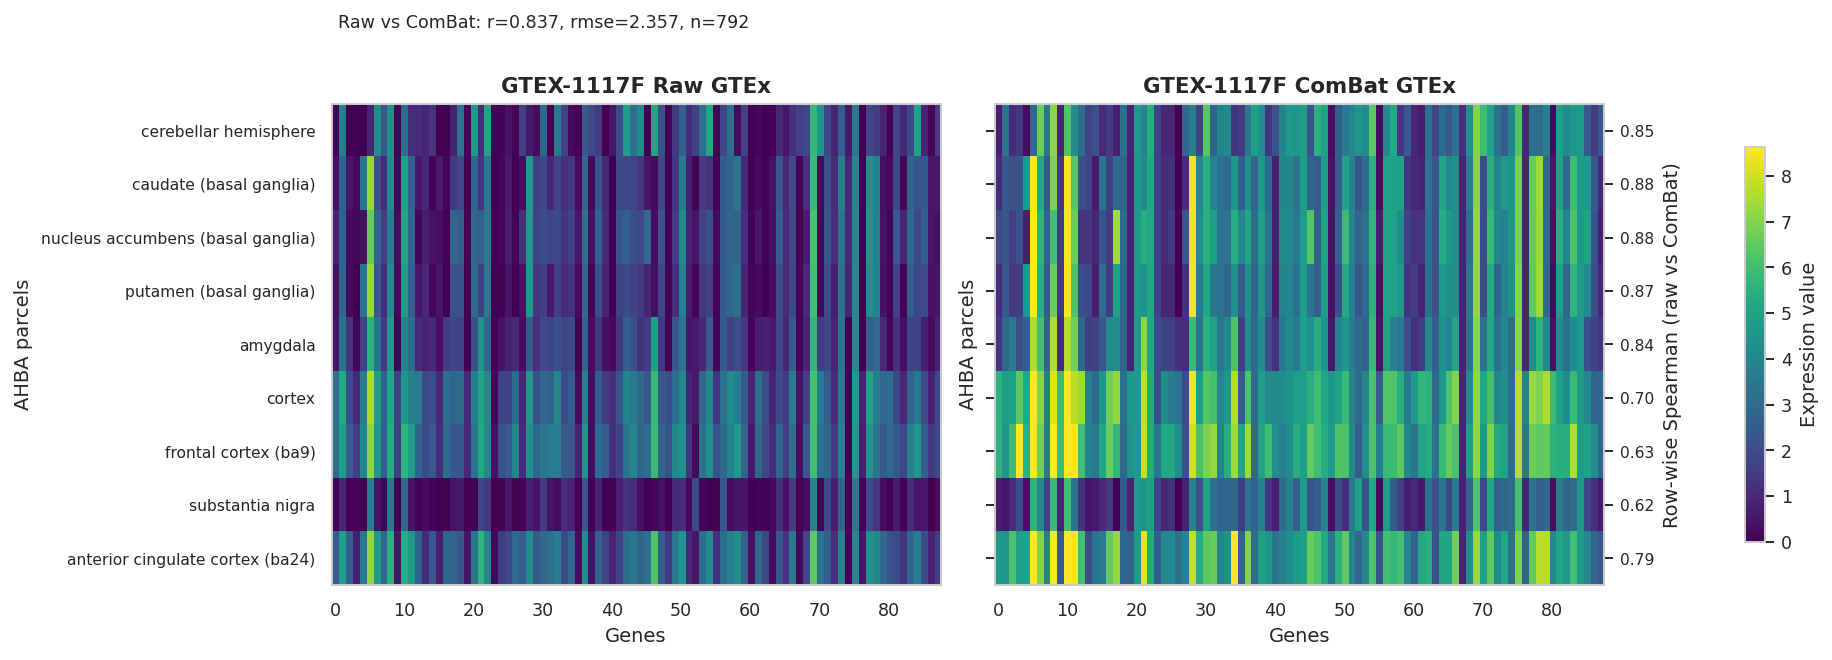

In [10]:
# Single-subject pre/post (GTEx only)
SUBJECT_ID = PREPOST['subjects'][0]
fig, axes = plot_subject_prepost_heatmaps(
    PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode=GENE_MODE,
    gene_list=CUSTOM_GENE_LIST,
    observed_only=True,
    label_stride=1,
)
print('subject:', SUBJECT_ID)


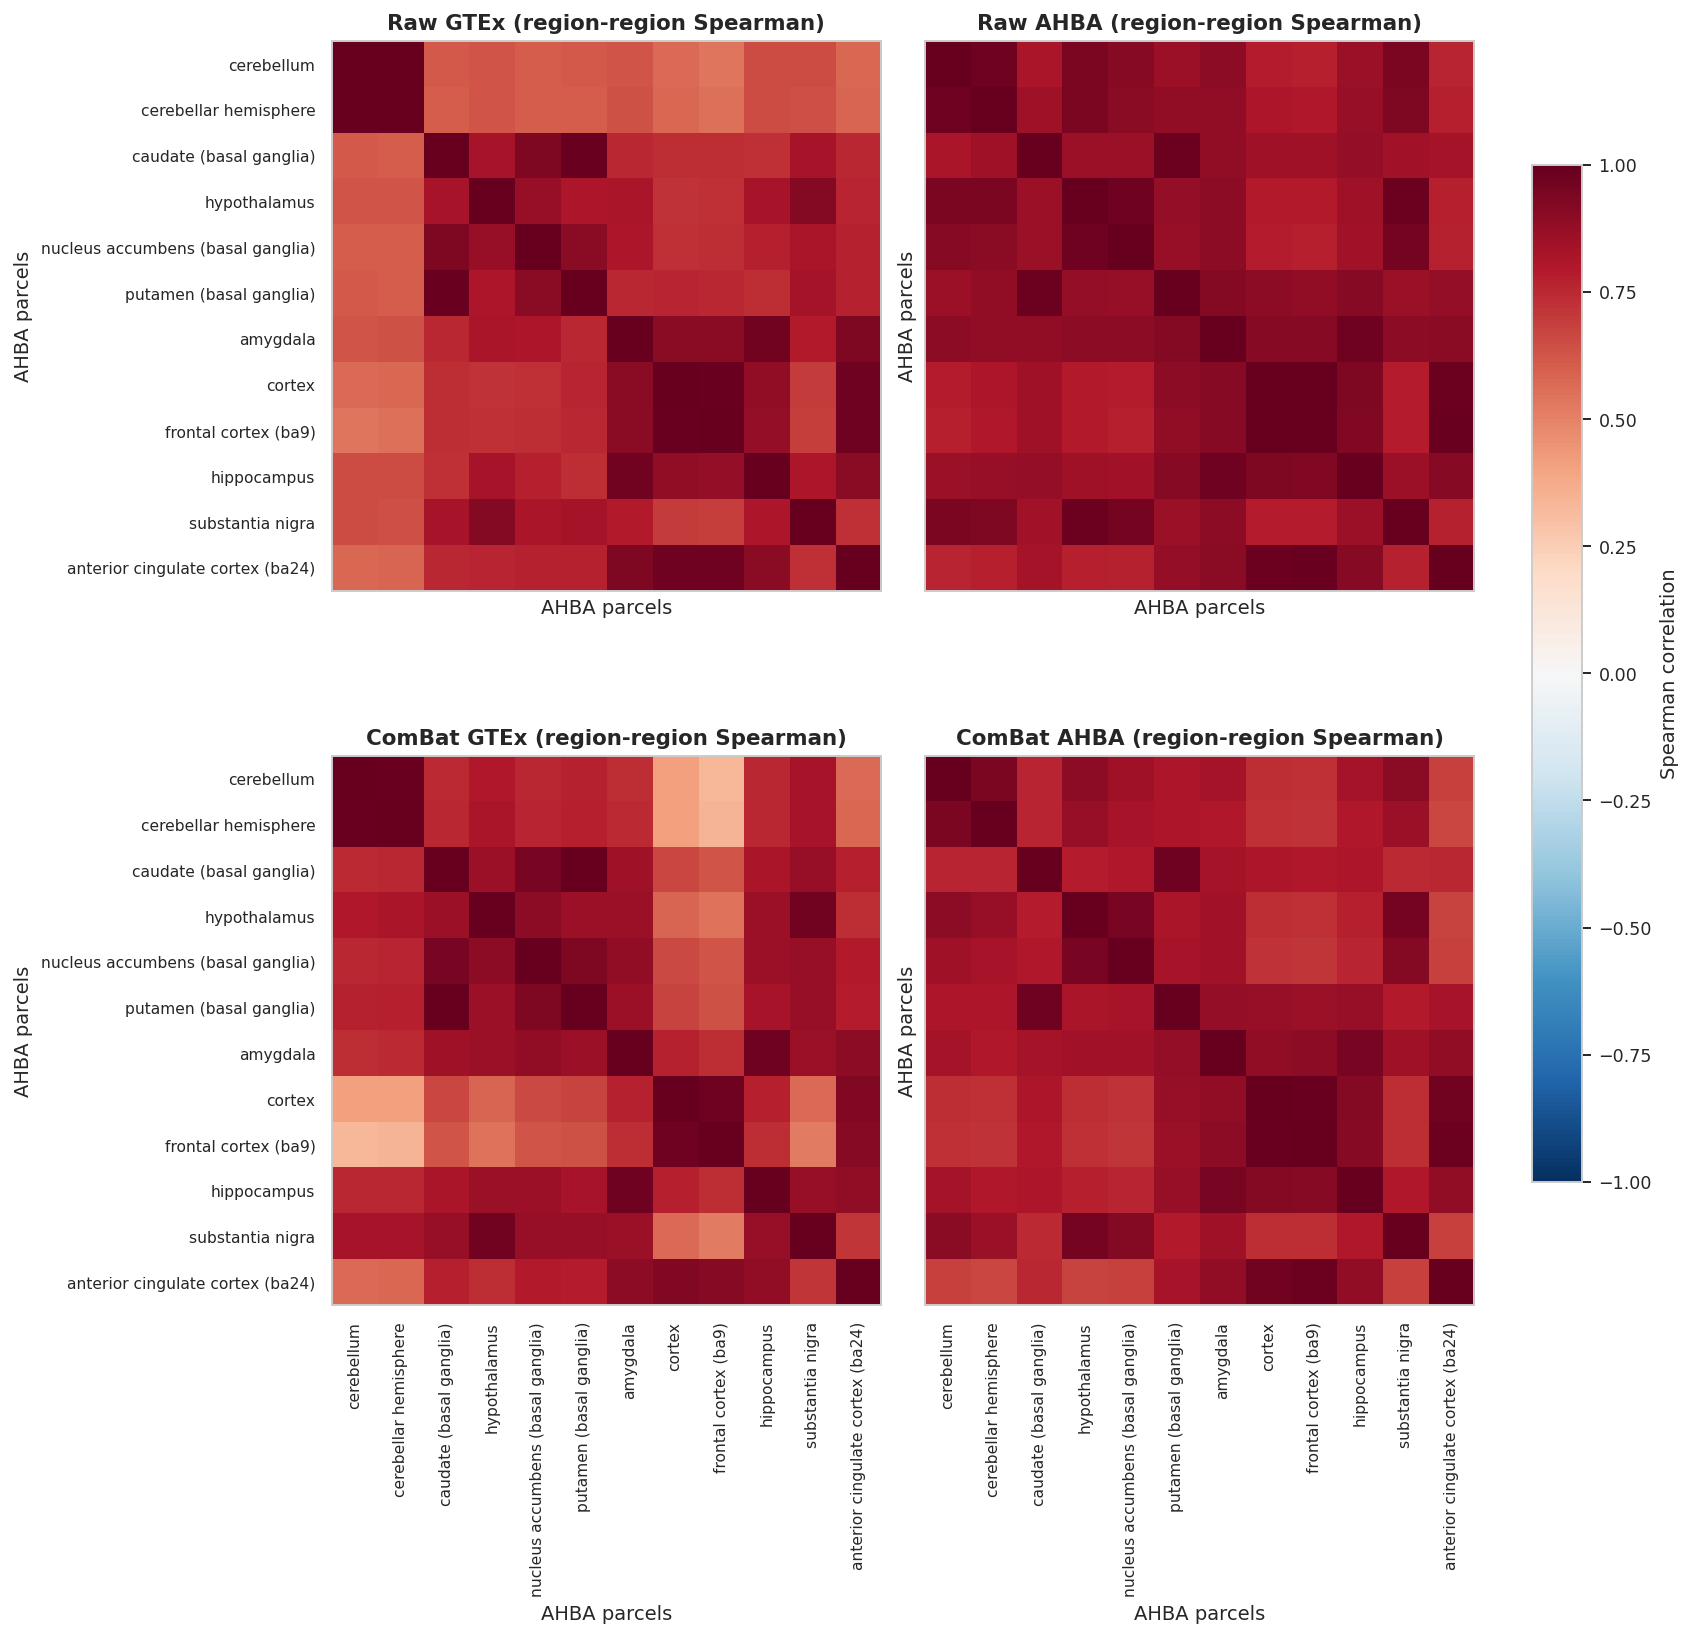

In [11]:
fig, axes = plot_region_region_spearman_heatmaps(atlas_cmp)


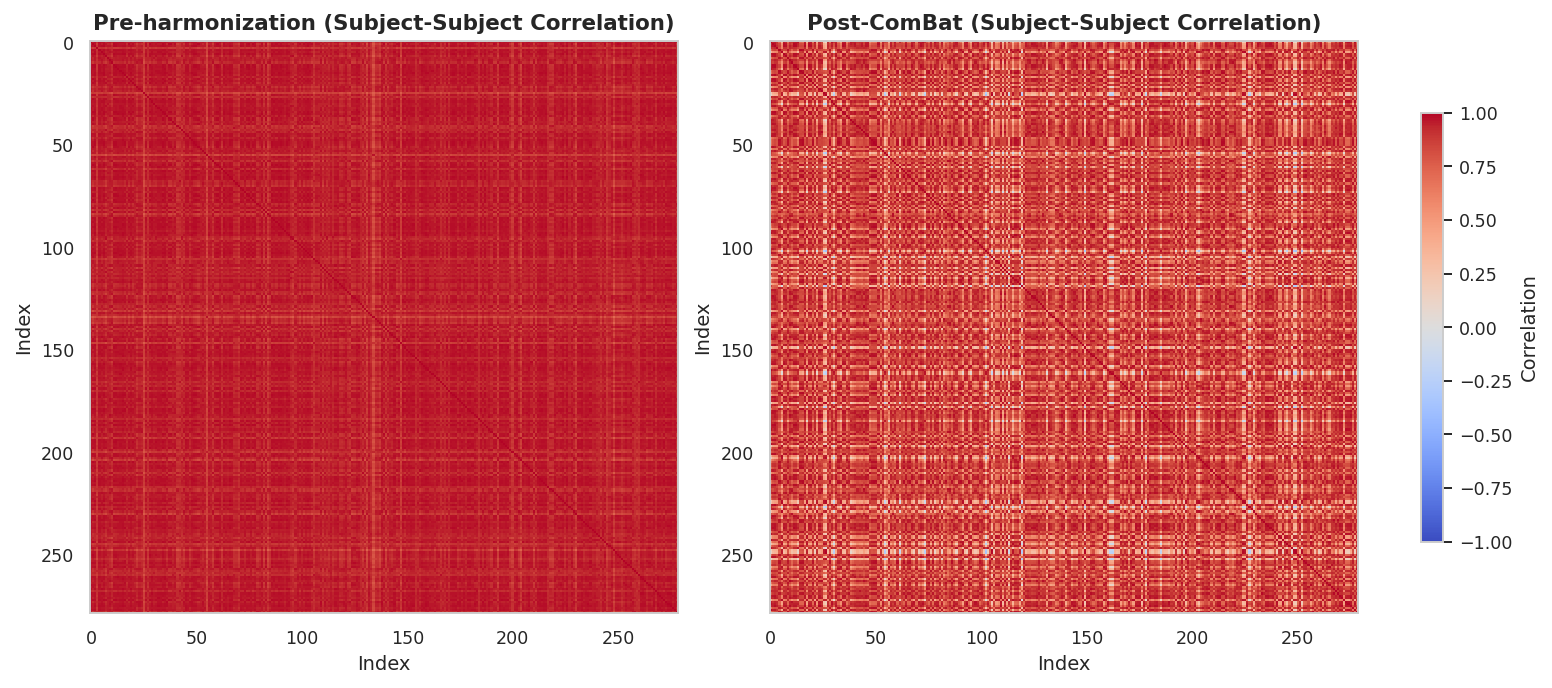

In [12]:
# Optional population-level region-wise subject-subject pre/post view
avail = available_regions(PREPOST, min_subjects=1)
REGION = int(avail.iloc[0]['parcel_idx'])
fig, axes = plot_region_covariance_side_by_side(PREPOST, region=REGION, mode='subject')


## 3) Coverage vs Accuracy


In [13]:
# allgenes-fit cache metrics, evaluated on all genes in inverse-ComBat GTEx space
naive_all = compute_subject_metrics_from_cache_gene_subset(CFG, model='naive', eval_gene_mode='all', inverse_combat=True)
dlam_all  = compute_subject_metrics_from_cache_gene_subset(CFG, model='dlam',  eval_gene_mode='all', inverse_combat=True)
plam_all  = compute_subject_metrics_from_cache_gene_subset(CFG, model='plam',  eval_gene_mode='all', inverse_combat=True)
metrics_allgenes_eval = pd.concat([naive_all, dlam_all, plam_all], ignore_index=True)

# allgenes-fit cache metrics, evaluated on HVG subset in inverse-ComBat GTEx space
naive_hvg = compute_subject_metrics_from_cache_gene_subset(CFG, model='naive', eval_gene_mode='hvg', inverse_combat=True)
dlam_hvg  = compute_subject_metrics_from_cache_gene_subset(CFG, model='dlam',  eval_gene_mode='hvg', inverse_combat=True)
plam_hvg  = compute_subject_metrics_from_cache_gene_subset(CFG, model='plam',  eval_gene_mode='hvg', inverse_combat=True)
metrics_hvg_eval_on_allgenes_fit = pd.concat([naive_hvg, dlam_hvg, plam_hvg], ignore_index=True)

display(metrics_allgenes_eval.head())
display(metrics_hvg_eval_on_allgenes_fit.head())


,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,inverse_combat,clamp_zero,n_points,pearson_r,rmse
0,GTEX-1192W,naive,5,5,13618,13618,all,None,True,False,68090,0.430477,2.301371
1,GTEX-131XW,naive,5,5,13618,13618,all,None,True,False,68090,0.387653,2.552407
2,GTEX-13NZA,naive,5,5,13618,13618,all,None,True,False,68090,0.396311,2.499928
3,GTEX-1477Z,naive,5,5,13618,13618,all,None,True,False,68090,0.415950,2.400410
4,GTEX-17MF6,naive,5,5,13618,13618,all,None,True,False,68090,0.382392,2.549286


,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,inverse_combat,clamp_zero,n_points,pearson_r,rmse
0,GTEX-1192W,naive,5,5,88,13618,hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,True,False,440,0.502513,3.019727
1,GTEX-131XW,naive,5,5,88,13618,hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,True,False,440,0.473151,3.315823
2,GTEX-13NZA,naive,5,5,88,13618,hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,True,False,440,0.359333,3.074211
3,GTEX-1477Z,naive,5,5,88,13618,hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,True,False,440,0.497555,3.271050
4,GTEX-17MF6,naive,5,5,88,13618,hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,True,False,440,0.485967,2.981901


In [14]:
metrics_allgenes_eval

,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,inverse_combat,clamp_zero,n_points,pearson_r,rmse
0,GTEX-1192W,naive,5,5,13618,13618,all,None,True,False,68090,0.430477,2.301371
1,GTEX-131XW,naive,5,5,13618,13618,all,None,True,False,68090,0.387653,2.552407
2,GTEX-13NZA,naive,5,5,13618,13618,all,None,True,False,68090,0.396311,2.499928
3,GTEX-1477Z,naive,5,5,13618,13618,all,None,True,False,68090,0.415950,2.400410
4,GTEX-17MF6,naive,5,5,13618,13618,all,None,True,False,68090,0.382392,2.549286
...,...,...,...,...,...,...,...,...,...,...,...,...,...
934,GTEX-1P4AB,plam,12,12,13618,13618,all,None,True,False,163416,0.608913,1.558753
935,GTEX-1PWST,plam,12,12,13618,13618,all,None,True,False,163416,0.601524,1.647290
936,GTEX-WHSE,plam,12,12,13618,13618,all,None,True,False,163416,0.591422,2.048970
937,GTEX-X4XX,plam,12,12,13618,13618,all,None,True,False,163416,0.594908,1.551733


In [15]:
import importlib
import src.eval_utils.results_eda
importlib.reload(src.eval_utils.results_eda)
from src.eval_utils.results_eda import *

,model,pearson_mean,pearson_std,rmse_mean,rmse_std,n_subjects,pearson_err,rmse_err
0,naive,0.391894,0.017927,2.543611,0.108484,313,0.017927,0.108484
1,dlam,0.857427,0.037987,0.795105,0.197934,313,0.037987,0.197934
2,plam,0.577637,0.039166,1.602762,0.144506,313,0.039166,0.144506


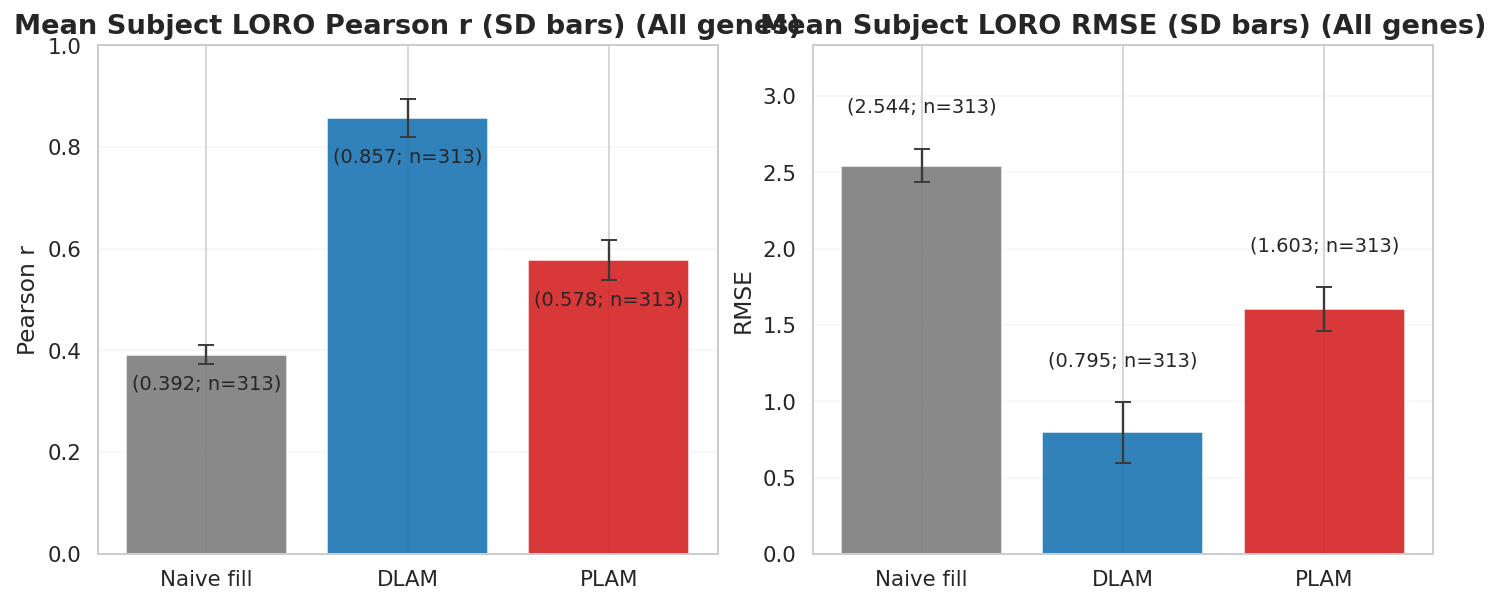

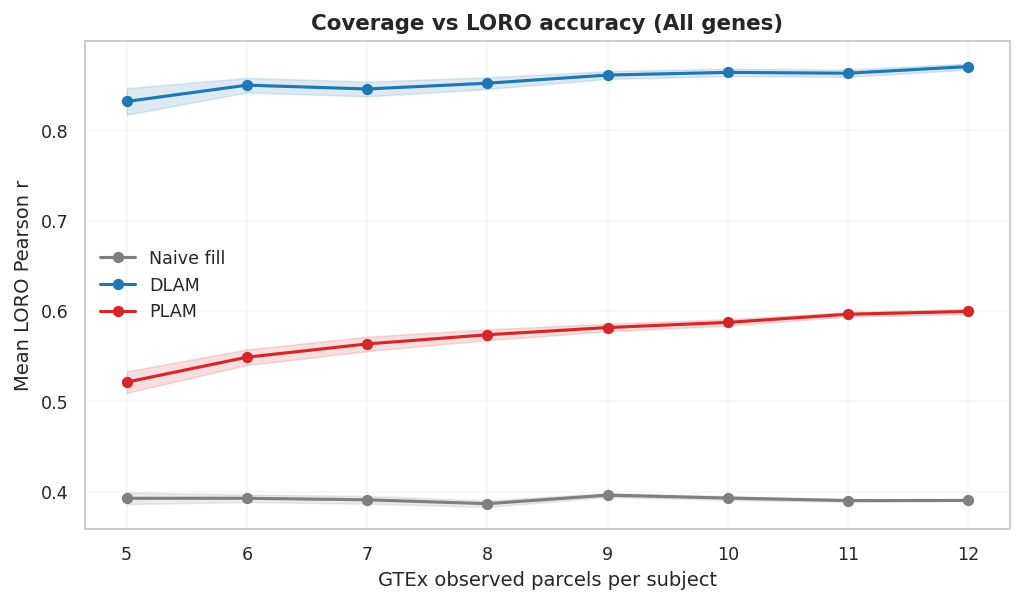

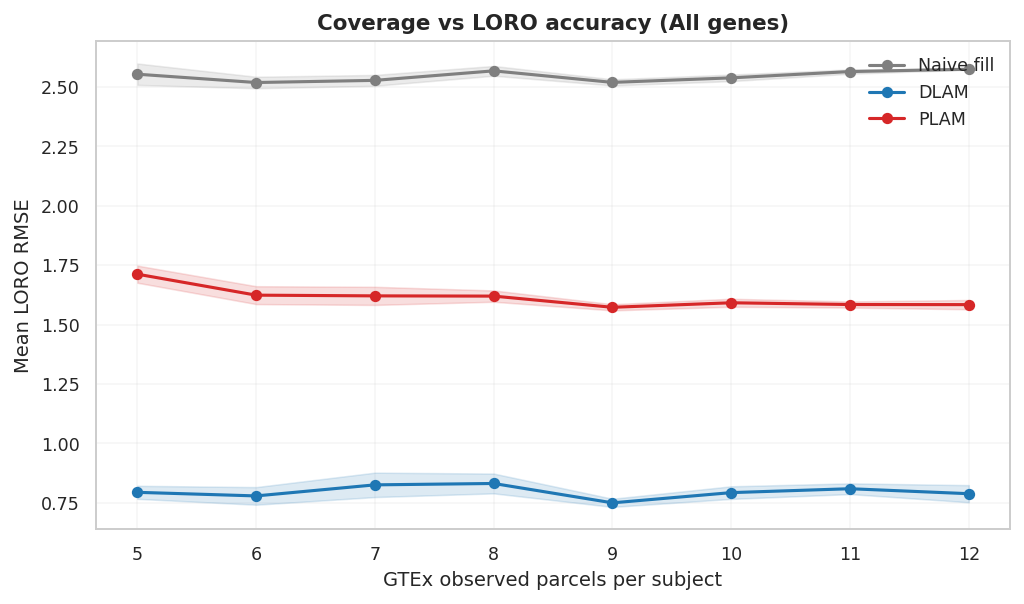

In [16]:
fig, axes, summary_all = plot_loro_subject_summary_bars(metrics_allgenes_eval, use_sem=False)
display(summary_all)
fig, ax = plot_coverage_vs_accuracy(metrics_allgenes_eval, metric='pearson_r')
fig, ax = plot_coverage_vs_accuracy(metrics_allgenes_eval, metric='rmse')


,model,pearson_mean,pearson_std,rmse_mean,rmse_std,n_subjects,pearson_err,rmse_err
0,naive,0.456004,0.071565,2.890250,0.189933,313,0.071565,0.189933
1,dlam,0.744308,0.088237,1.191363,0.272377,313,0.088237,0.272377
2,plam,0.371137,0.089860,2.885034,0.346102,313,0.089860,0.346102


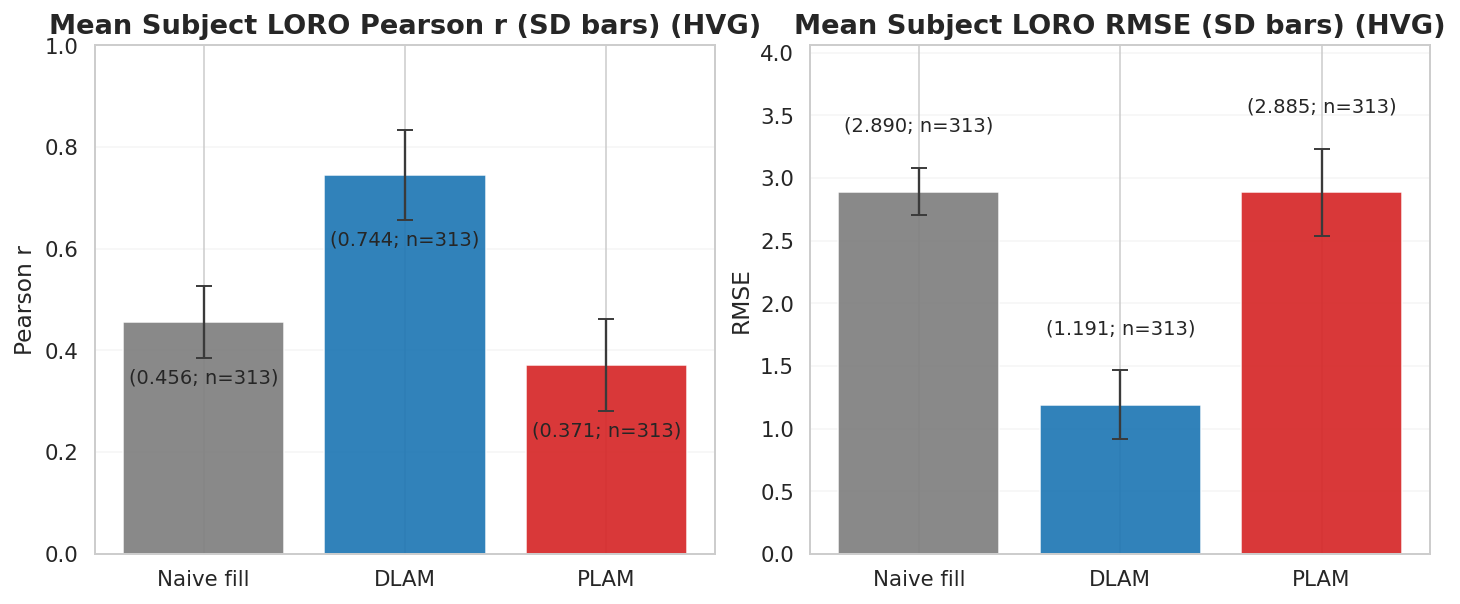

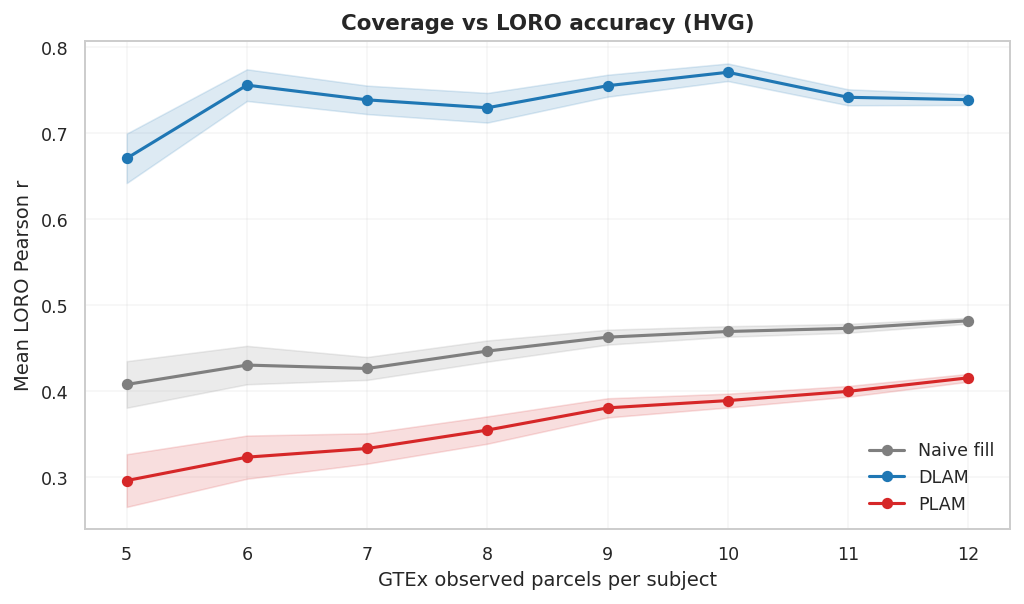

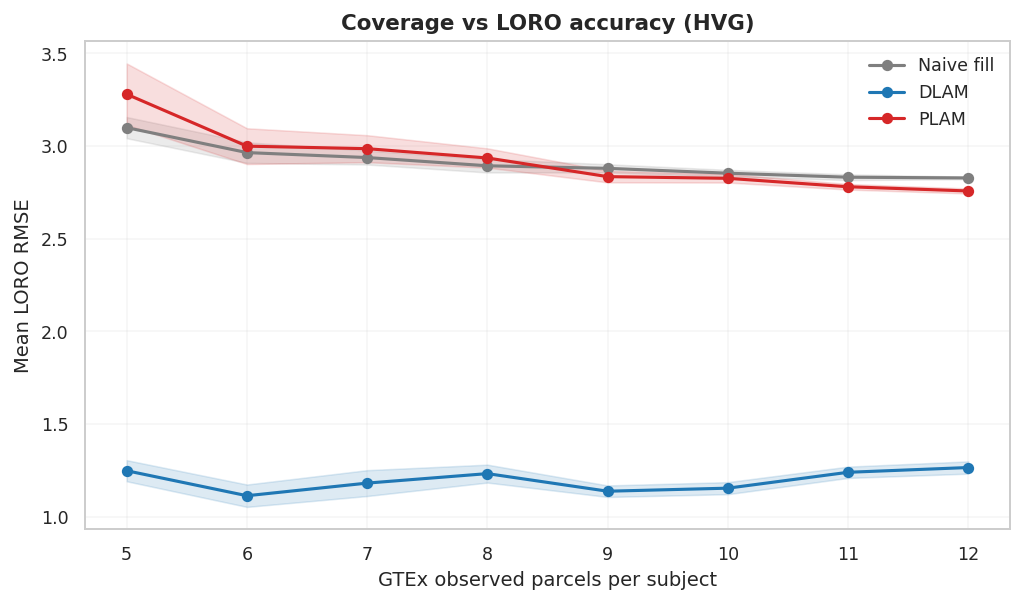

In [17]:
fig, axes, summary_hvg = plot_loro_subject_summary_bars(metrics_hvg_eval_on_allgenes_fit, use_sem=False)
display(summary_hvg)
fig, ax = plot_coverage_vs_accuracy(metrics_hvg_eval_on_allgenes_fit, metric='pearson_r')
fig, ax = plot_coverage_vs_accuracy(metrics_hvg_eval_on_allgenes_fit, metric='rmse')


## 4) Fold-Combo Difficulty


In [18]:
fold_perf_df, combo_df = compute_fold_combo_metrics_from_cache(
    CFG, PREPOST,
    eval_gene_mode='all',
    custom_gene_list=None,
    coverage_min=5,
    coverage_max=11,
    models=['naive', 'dlam', 'plam'],
    inverse_combat=True,
)
print('fold_perf_df:', fold_perf_df.shape)
print('combo_df:', combo_df.shape)
display(combo_df.head())


fold_perf_df: (7344, 14)
combo_df: (4458, 13)


,coverage,fold_key,model,n_subjects,mean_pearson,std_pearson,mean_rmse,std_rmse,mean_points,eval_gene_mode,eval_gene_path,inverse_combat,clamp_zero
0,5,"hold=0|train=10,16,31,132",dlam,1,0.676072,NaN,1.076133,NaN,13618.0,all,None,True,False
1,5,"hold=0|train=10,16,31,94",dlam,1,0.709107,NaN,1.193678,NaN,13618.0,all,None,True,False
2,5,"hold=0|train=31,38,55,94",dlam,1,0.720426,NaN,1.072146,NaN,13618.0,all,None,True,False
3,5,"hold=0|train=5,10,29,132",dlam,1,0.860553,NaN,0.747154,NaN,13618.0,all,None,True,False
4,5,"hold=0|train=5,16,31,94",dlam,1,0.912147,NaN,0.746846,NaN,13618.0,all,None,True,False


,rank_tag,model,metric,score,coverage,n_subjects,fold_key,hold_parcel,hold_gtex,train_parcels,train_gtex
0,worst,naive,mean_pearson,0.243746,8,1,"hold=94|train=0,5,10,16,31,55,132",94,substantia nigra,"[0, 5, 10, 16, 31, 55, 132]","[cerebellum, cerebellar hemisphere, caudate (b..."
1,median,naive,mean_pearson,0.391216,10,1,"hold=18|train=0,10,16,19,31,38,55,94,132",18,nucleus accumbens (basal ganglia),"[0, 10, 16, 19, 31, 38, 55, 94, 132]","[cerebellum, caudate (basal ganglia), hypothal..."
2,best,naive,mean_pearson,0.580175,10,1,"hold=132|train=5,10,16,18,19,29,31,38,94",132,anterior cingulate cortex (ba24),"[5, 10, 16, 18, 19, 29, 31, 38, 94]","[cerebellar hemisphere, caudate (basal ganglia..."


,rank_tag,model,metric,score,coverage,n_subjects,fold_key,hold_parcel,hold_gtex,train_parcels,train_gtex
0,worst,dlam,mean_pearson,0.639092,6,1,"hold=0|train=16,29,38,55,132",0,cerebellum,"[16, 29, 38, 55, 132]","[hypothalamus, amygdala, frontal cortex (ba9),..."
1,median,dlam,mean_pearson,0.884440,9,1,"hold=18|train=0,5,10,19,31,38,94,132",18,nucleus accumbens (basal ganglia),"[0, 5, 10, 19, 31, 38, 94, 132]","[cerebellum, cerebellar hemisphere, caudate (b..."
2,best,dlam,mean_pearson,0.957733,7,1,"hold=10|train=0,5,16,18,19,38",10,caudate (basal ganglia),"[0, 5, 16, 18, 19, 38]","[cerebellum, cerebellar hemisphere, hypothalam..."


,rank_tag,model,metric,score,coverage,n_subjects,fold_key,hold_parcel,hold_gtex,train_parcels,train_gtex
0,worst,plam,mean_pearson,0.368749,7,1,"hold=31|train=0,5,18,29,55,94",31,cortex,"[0, 5, 18, 29, 55, 94]","[cerebellum, cerebellar hemisphere, nucleus ac..."
1,median,plam,mean_pearson,0.585398,11,8,"hold=0|train=5,10,16,18,19,29,31,38,55,94",0,cerebellum,"[5, 10, 16, 18, 19, 29, 31, 38, 55, 94]","[cerebellar hemisphere, caudate (basal ganglia..."
2,best,plam,mean_pearson,0.909624,6,1,"hold=10|train=16,18,19,29,38",10,caudate (basal ganglia),"[16, 18, 19, 29, 38]","[hypothalamus, nucleus accumbens (basal gangli..."


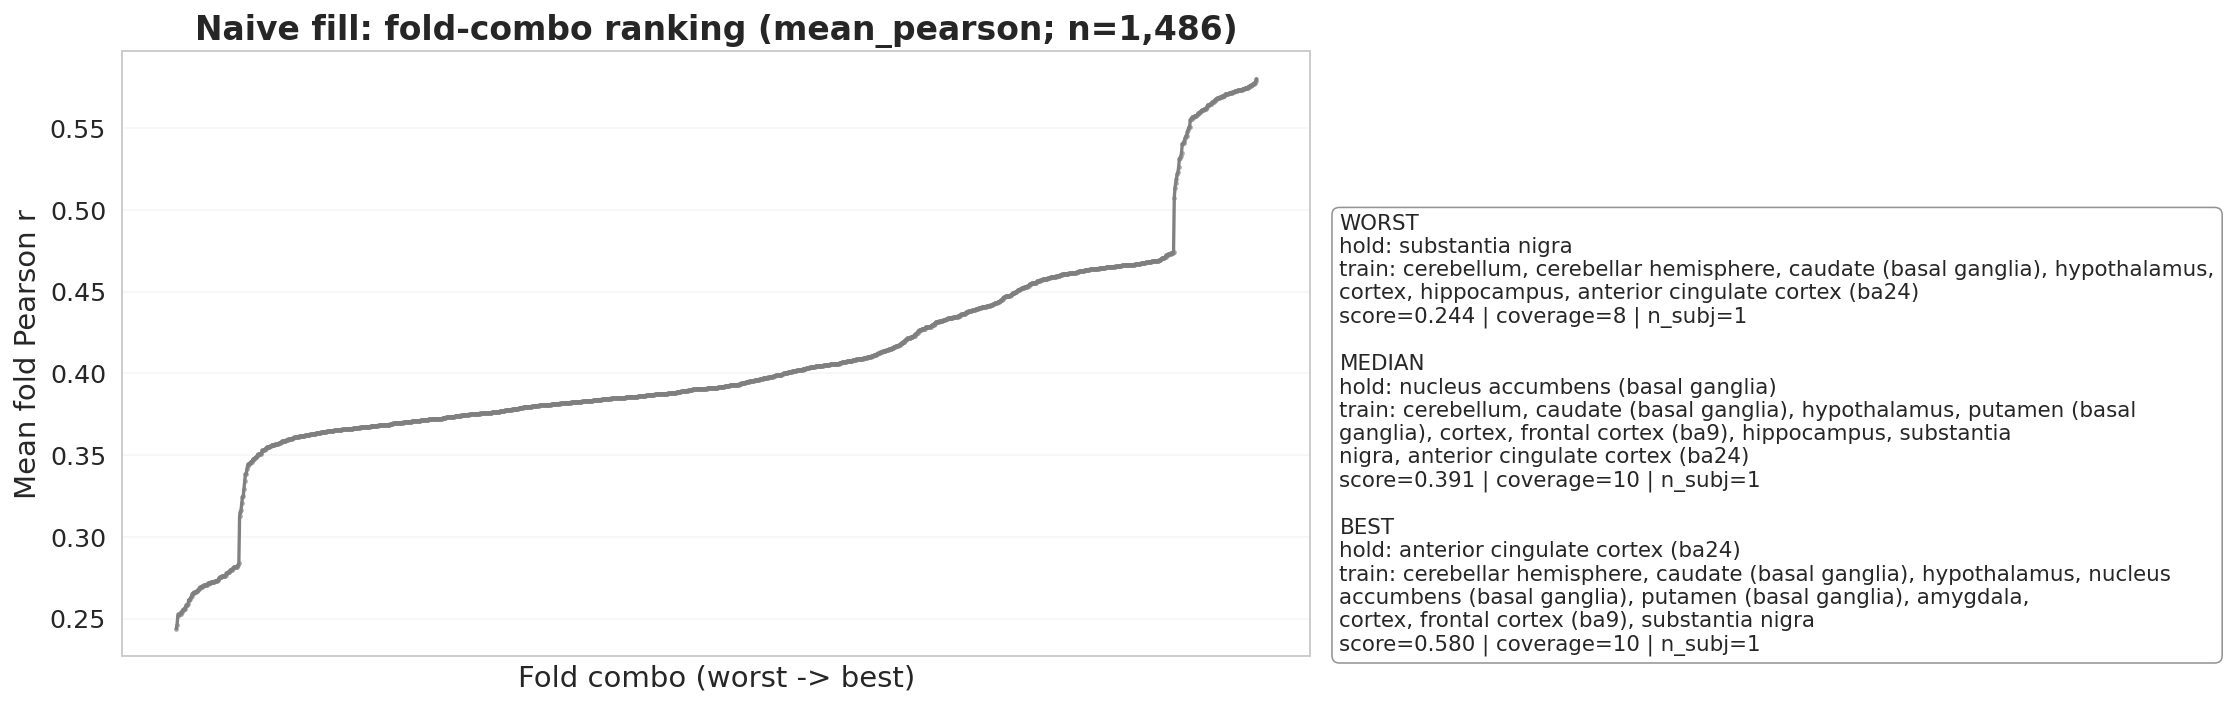

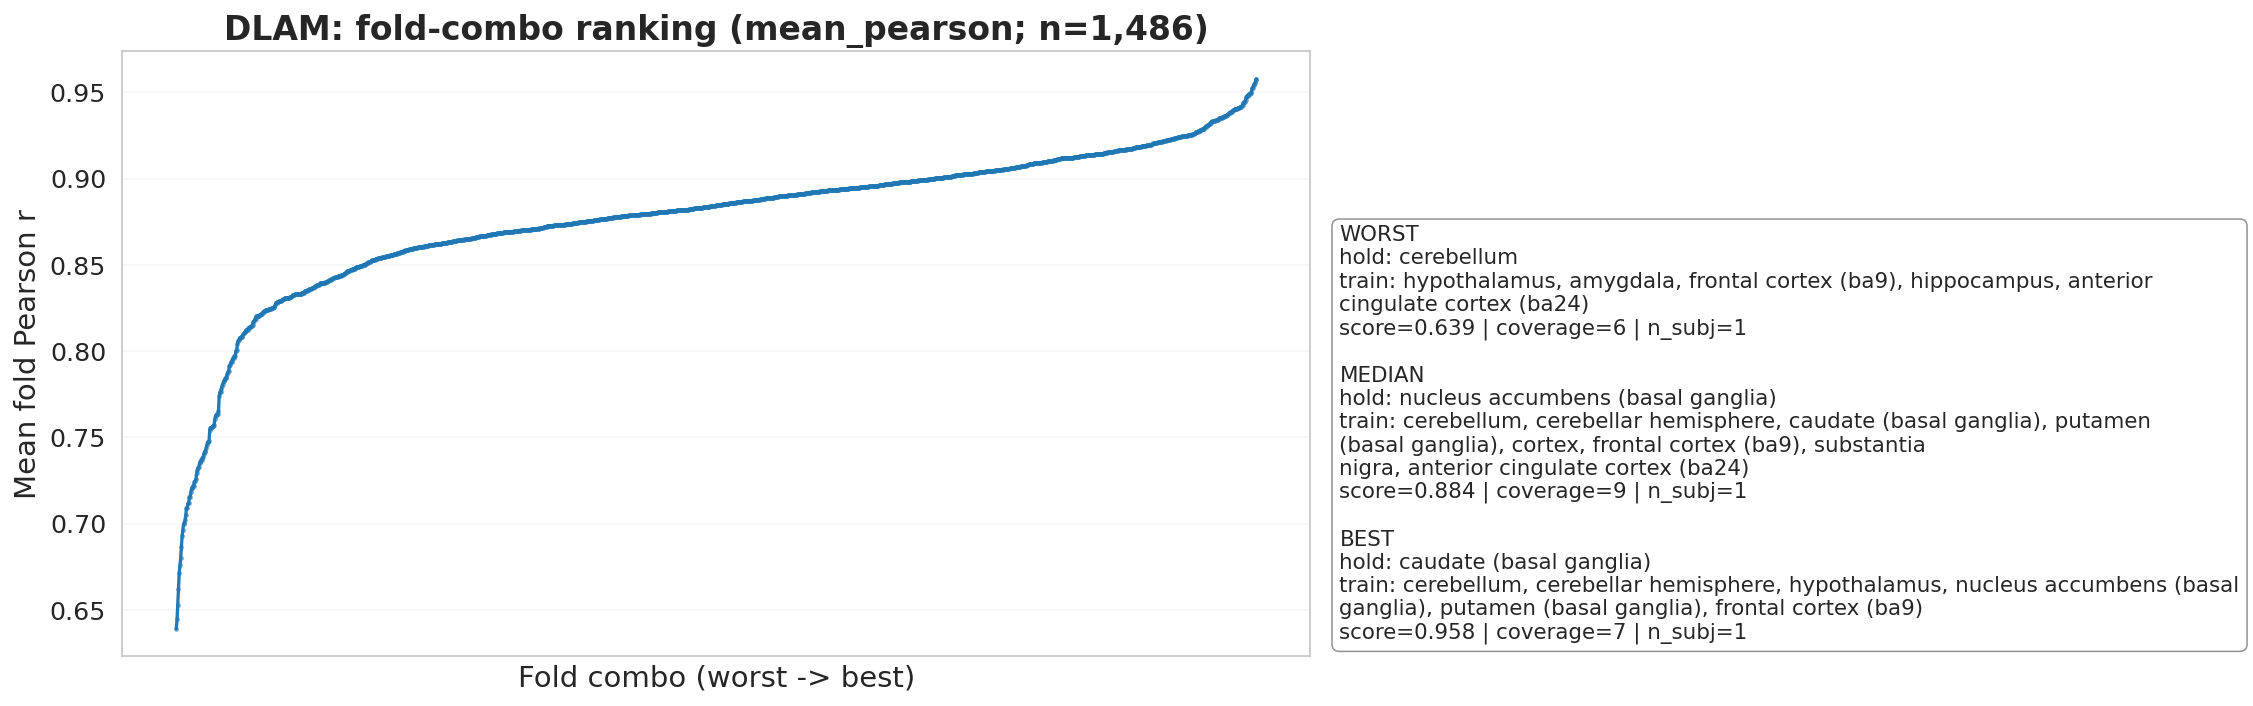

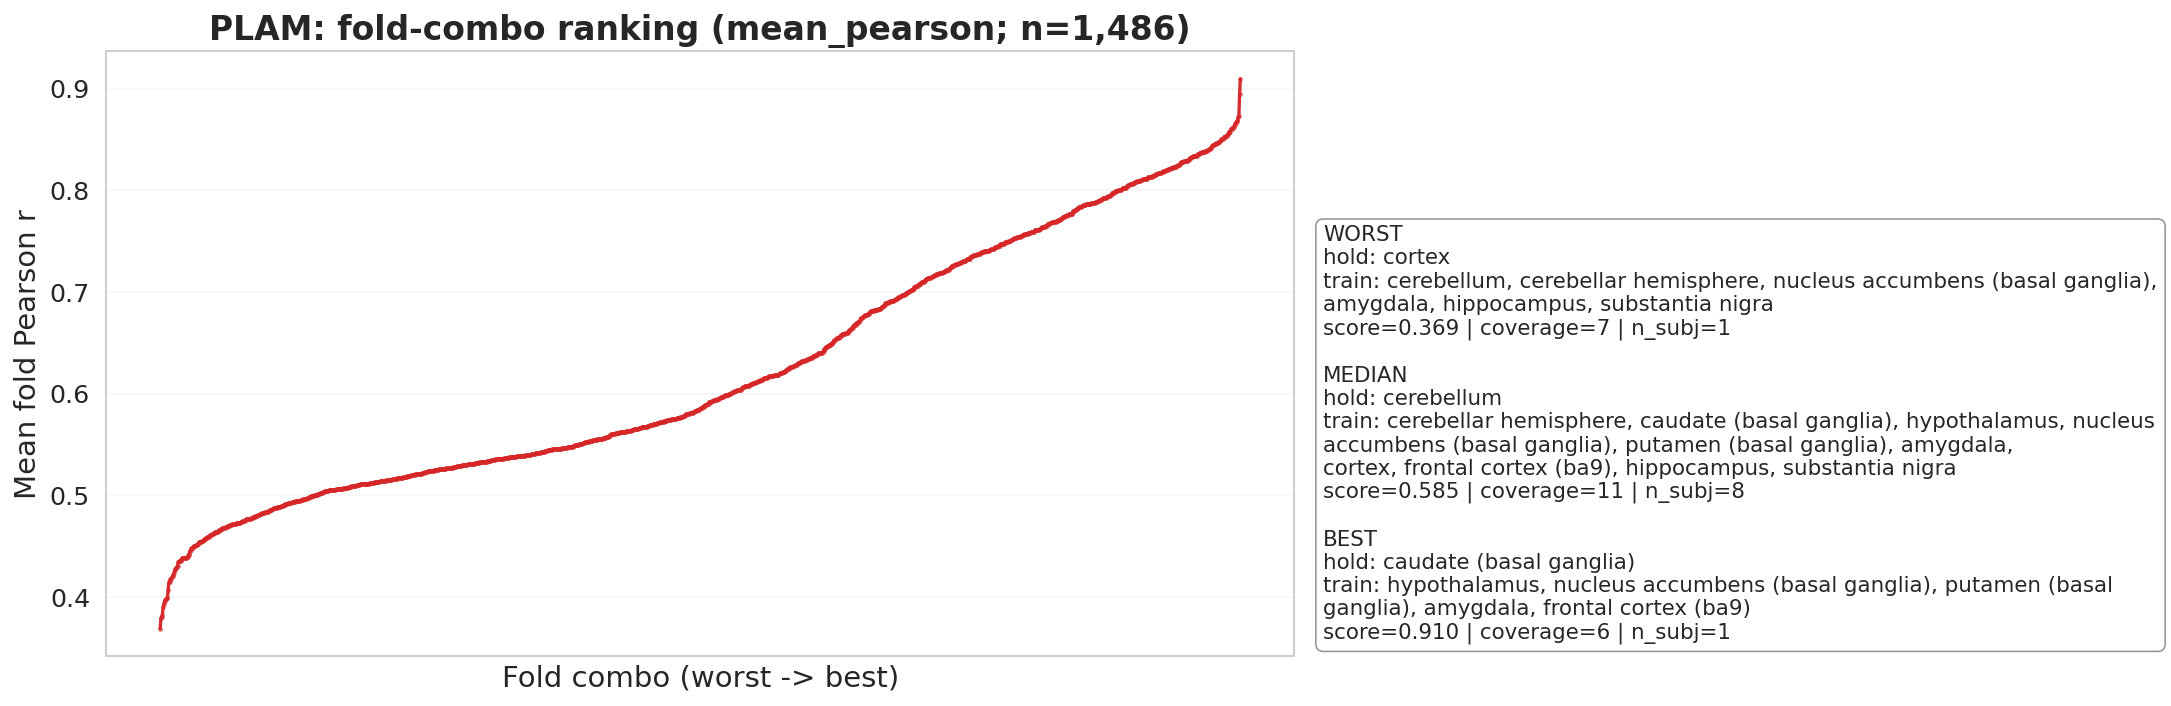

In [19]:
for model_name in ['naive', 'dlam', 'plam']:
    fig, ax, key_table = plot_fold_combo_ranked(combo_df, PREPOST, model=model_name, metric='mean_pearson')
    display(key_table)


,hold_parcel,model,n_subjects,n_folds,mean_pearson,std_pearson,mean_rmse,std_rmse,gtex_label,ahba_label,label
0,0,dlam,216,216,0.863096,0.060393,0.877593,0.242321,cerebellum,Cerebellar_Region1,cerebellum
1,0,naive,216,216,0.367681,0.007033,2.553881,0.022574,cerebellum,Cerebellar_Region1,cerebellum
2,0,plam,216,216,0.551359,0.038816,1.729046,0.180919,cerebellum,Cerebellar_Region1,cerebellum
3,5,dlam,227,227,0.850998,0.063480,0.916071,0.262569,cerebellar hemisphere,Cerebellar_Region5,cerebellar hemisphere
4,5,naive,227,227,0.465114,0.005181,2.133116,0.027501,cerebellar hemisphere,Cerebellar_Region5,cerebellar hemisphere
5,5,plam,227,227,0.529415,0.027572,1.911510,0.141904,cerebellar hemisphere,Cerebellar_Region5,cerebellar hemisphere
6,10,dlam,243,243,0.902235,0.029194,0.705805,0.236412,caudate (basal ganglia),LH-Ca,caudate (basal ganglia)
7,10,naive,243,243,0.432691,0.011242,2.310072,0.045737,caudate (basal ganglia),LH-Ca,caudate (basal ganglia)
8,10,plam,243,243,0.816034,0.041994,0.880032,0.180448,caudate (basal ganglia),LH-Ca,caudate (basal ganglia)
9,16,dlam,207,207,0.870498,0.026957,0.786828,0.227792,hypothalamus,LH-HTH,hypothalamus


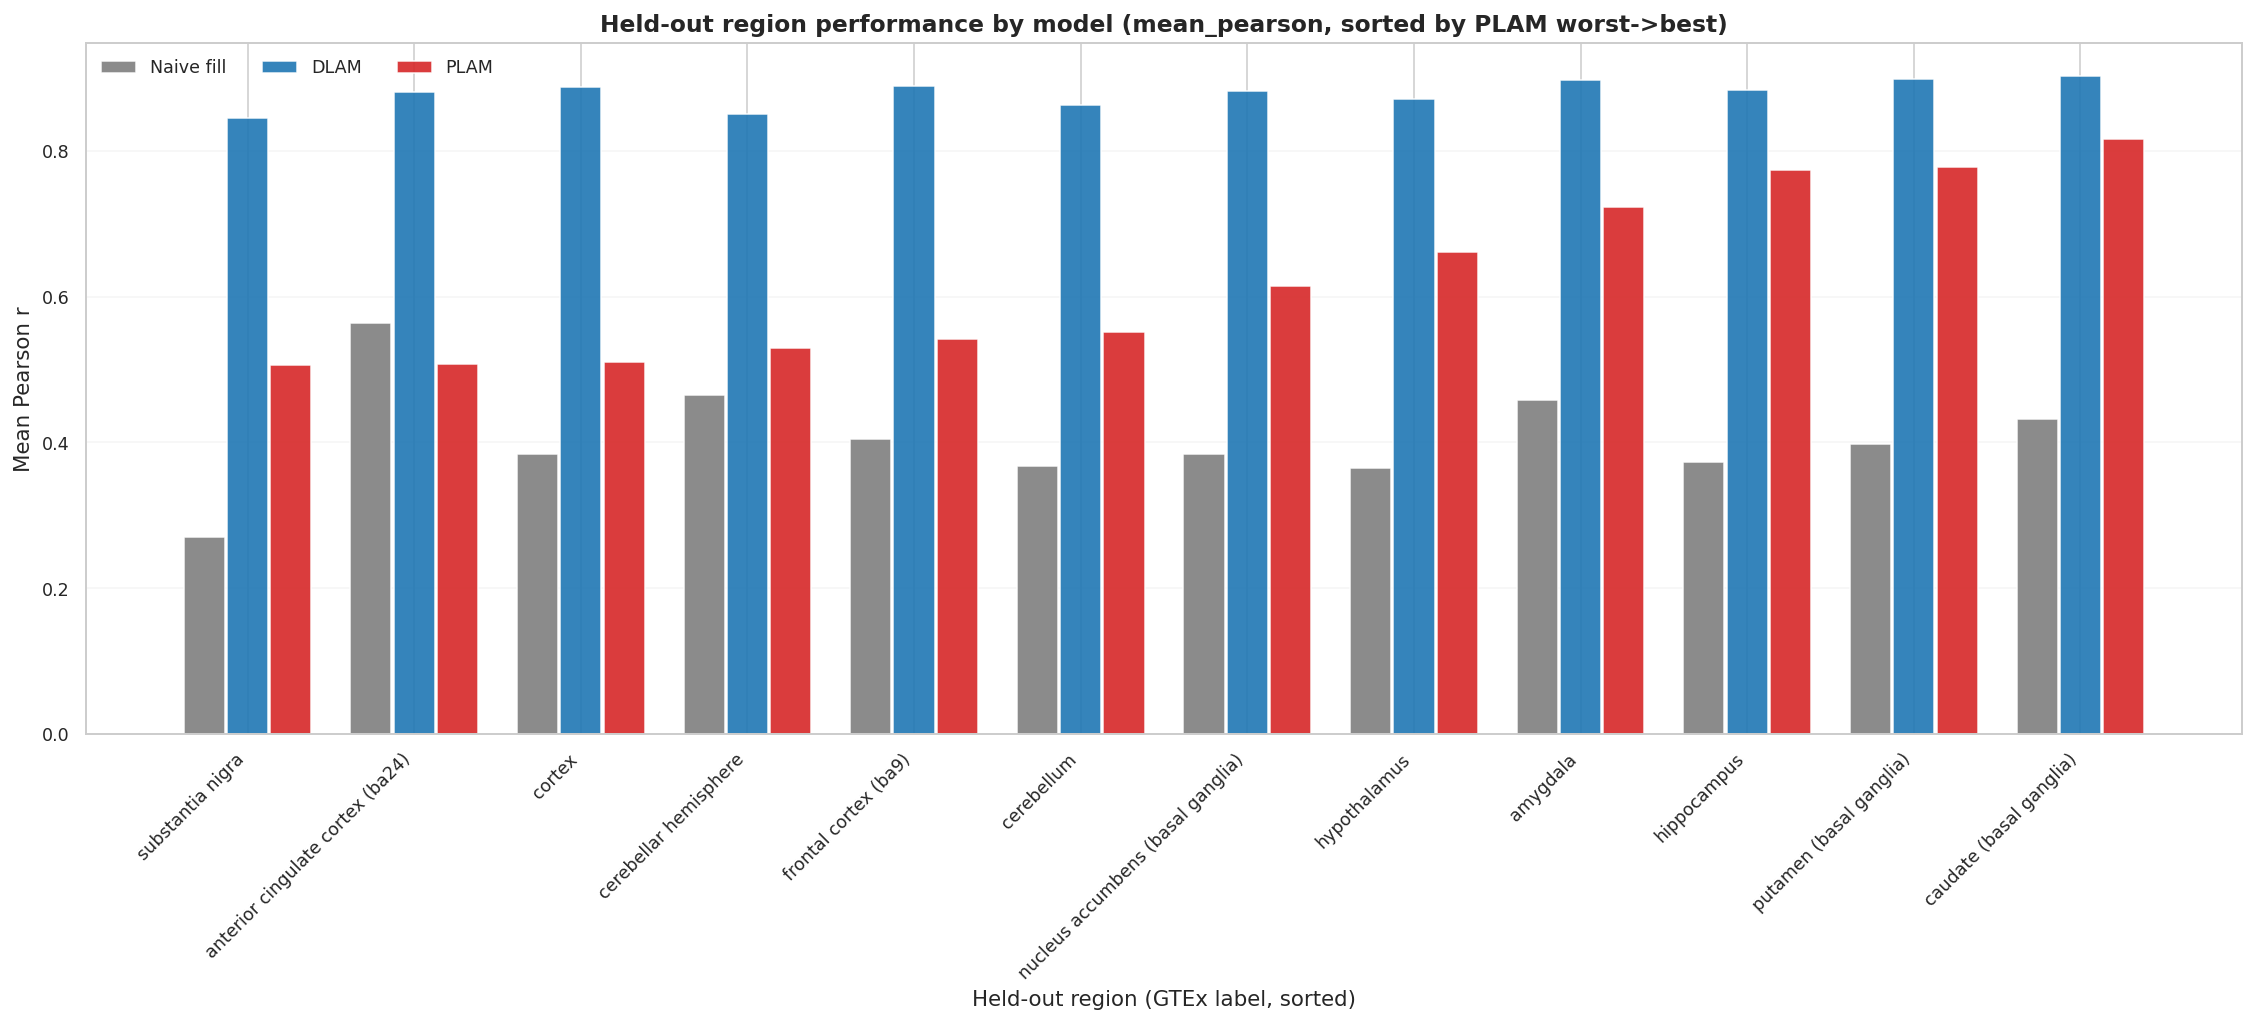

In [20]:
heldout_df = summarize_heldout_region_performance(fold_perf_df, PREPOST)
fig, ax, heldout_plot_df = plot_heldout_region_grouped_bars(
    heldout_df,
    metric='mean_pearson',
    sort_by_model='plam',
    use_error_bars=False,
    error_kind='std',
)
display(heldout_df.head(20))


## 5) Single-Subject Scatter Triplets


subject: GTEX-144GL


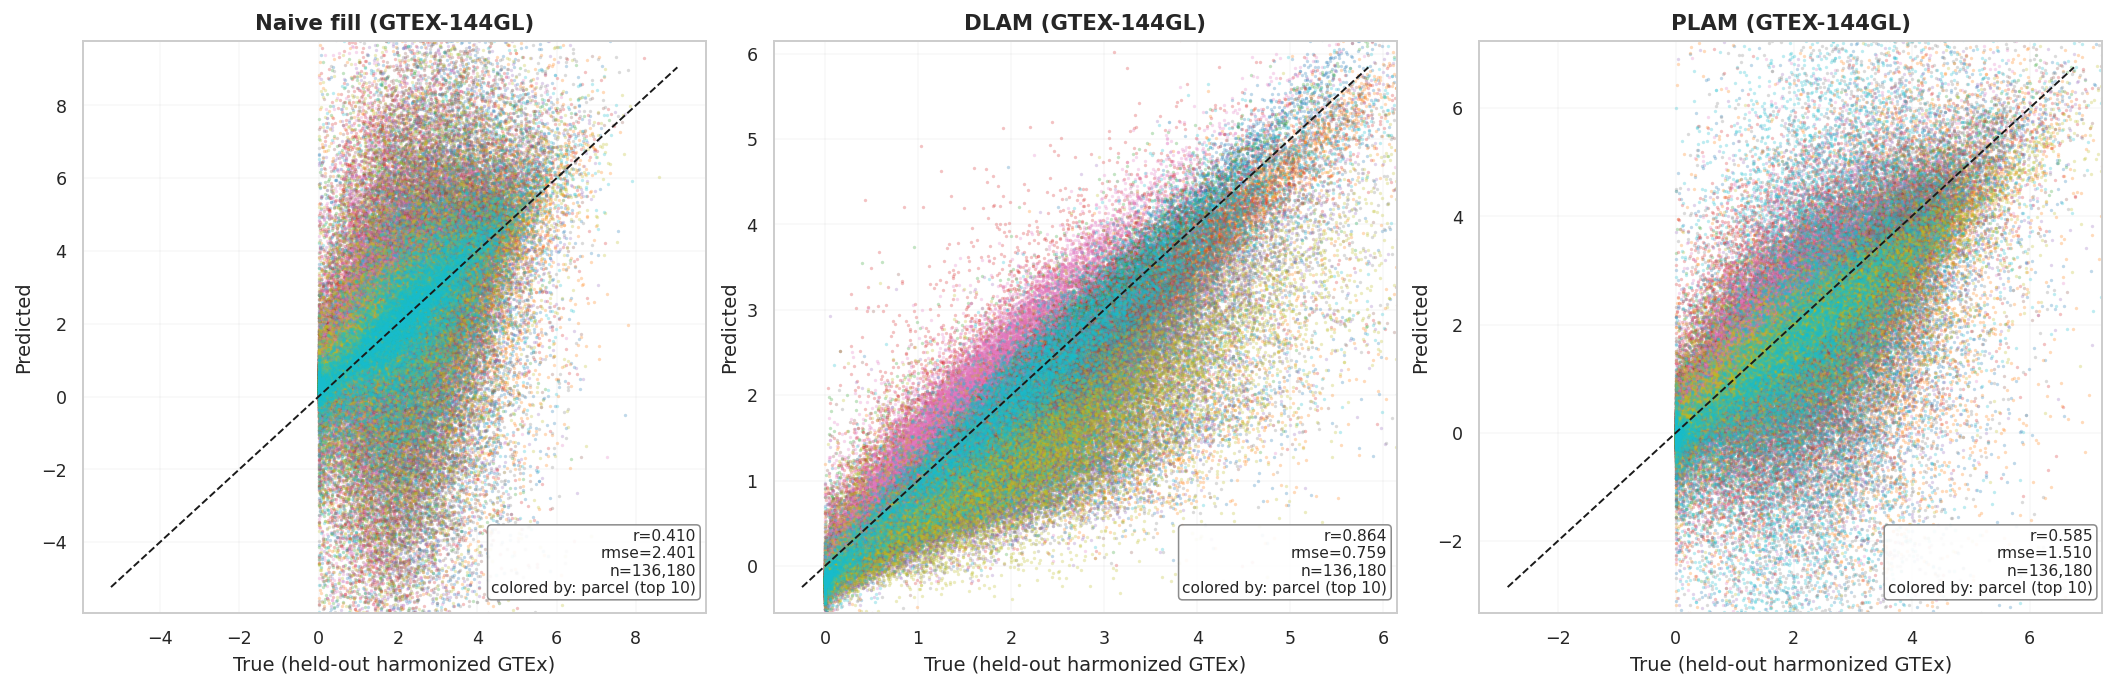

In [21]:
fig, axes, subject = plot_single_subject_scatter_triplet(
    CFG,
    subject_mode='median',
    color_by='parcel',
    top_n=10,
    inverse_combat=True,
)
print('subject:', subject)


subject: GTEX-144GL


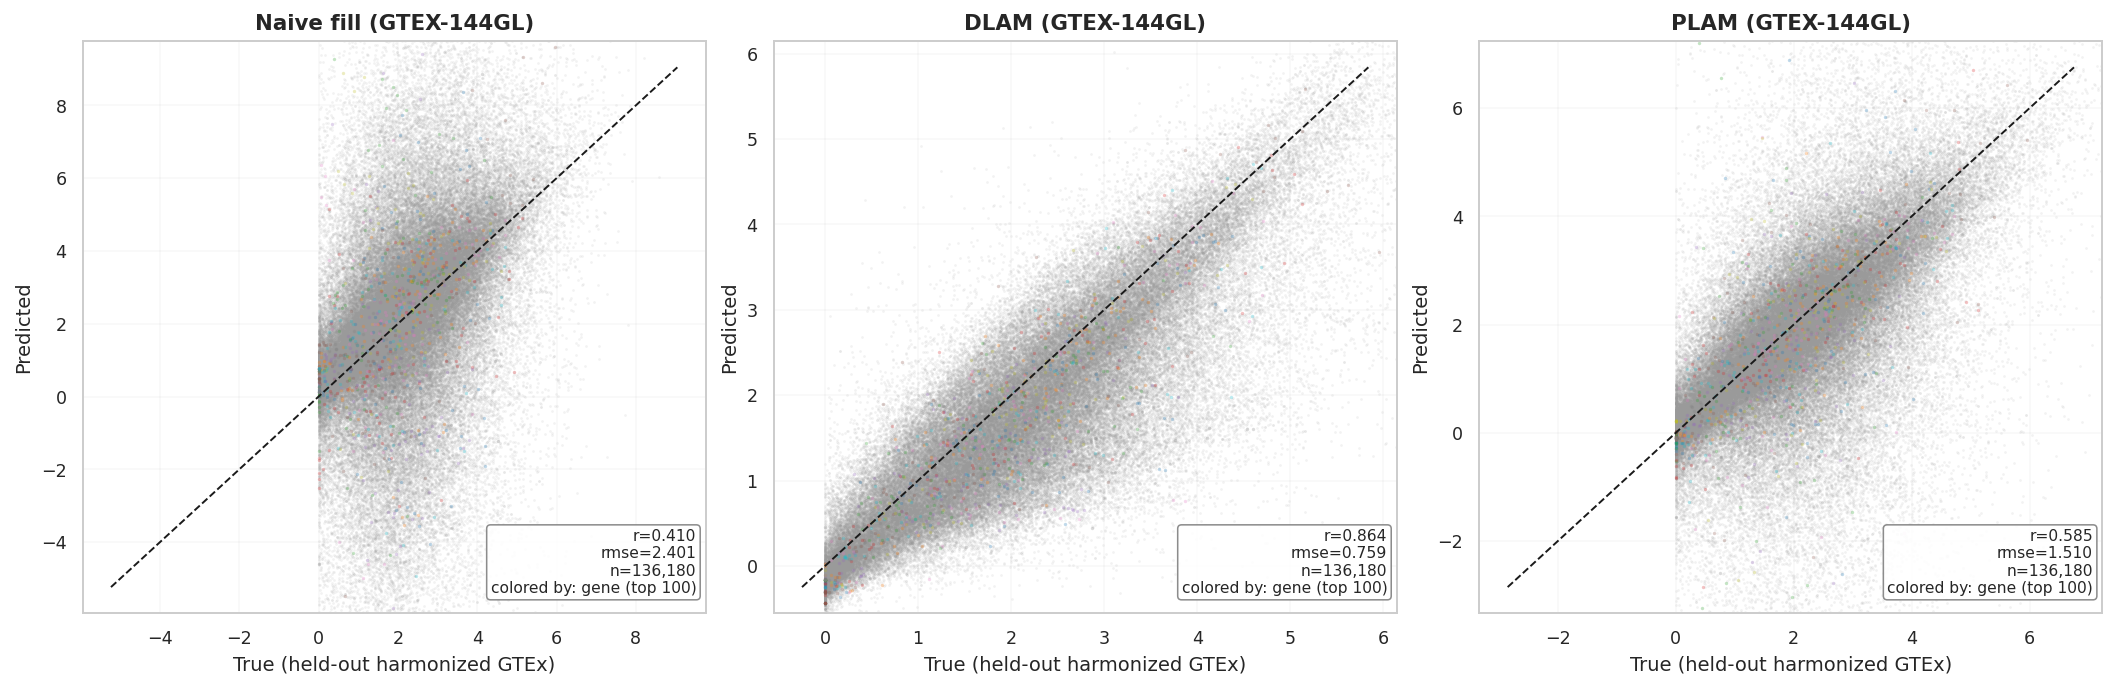

In [22]:
fig, axes, subject = plot_single_subject_scatter_triplet(
    CFG,
    subject_mode='median',
    color_by='gene',
    top_n=100,
    inverse_combat=True,
)
print('subject:', subject)
